In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

In [3]:
df = pd.read_excel("../data/FinalAllotment.xlsx")

In [124]:
df.head()

df.shape

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Sl. No.    1825 non-null   int64
 1   KEAM Rank  1825 non-null   int64
 2   Category   1825 non-null   str  
 3   Course     1825 non-null   str  
 4   Seat Type  1825 non-null   str  
dtypes: int64(2), str(3)
memory usage: 71.4 KB


In [58]:
df.isnull().sum()

Sl. No.      0
KEAM Rank    0
Category     0
Course       0
Seat Type    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['KEAM Rank'].describe()

count     1825.000000
mean      6594.836164
std       7852.621774
min         47.000000
25%       2301.000000
50%       4025.000000
75%       7966.000000
max      67069.000000
Name: KEAM Rank, dtype: float64

In [7]:
df['Course'].value_counts()

Course
CS- Computer Science & Engineering           550
EC- Electronics & Communication              365
EB- Electronics & Biomedical Engg            183
EV- Electronics Engineering (VLSI Design)    183
CU- Computer Science and Business Systems    182
EE- Electrical & Electronics                 181
ME- Mechanical Engineering                   181
Name: count, dtype: int64

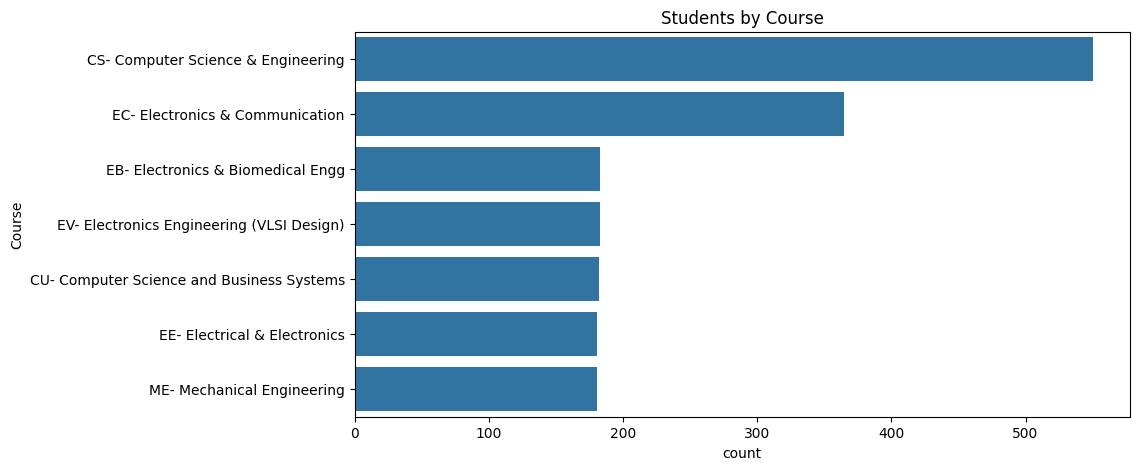

In [8]:
plt.figure(figsize=(10,5))

sns.countplot(
    y=df['Course'],
    order=df['Course'].value_counts().index
)

plt.title("Students by Course")
plt.show()

In [125]:
df['Category'].value_counts()

Category
GN    1060
EZ     214
MU     213
EW      94
SC      79
BH      51
VK      30
LA      28
DV      19
BX      12
KU       9
KN       9
ST       7
Name: count, dtype: int64

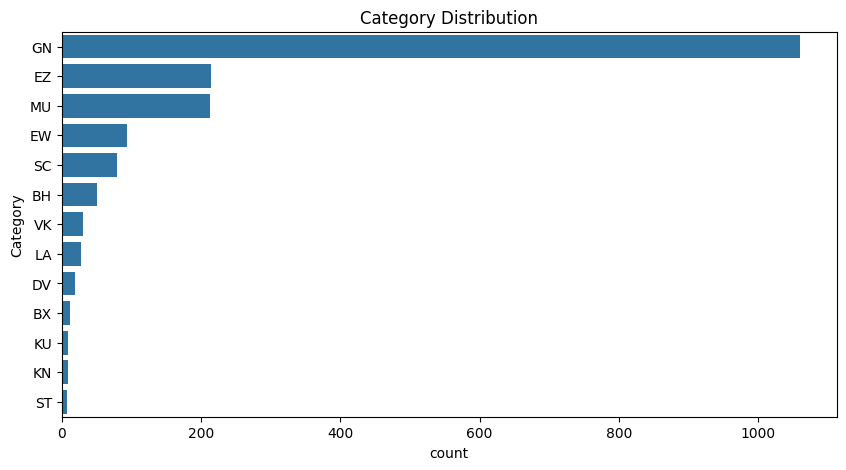

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(
    y=df['Category'],
    order=df['Category'].value_counts().index
)

plt.title("Category Distribution")
plt.show()

In [11]:
df['Seat Type'].value_counts()

Seat Type
MG    810
SM    465
EW     93
FW     90
EZ     83
SC     79
MU     74
BH     28
LA     27
VK     19
DV     19
KU      9
BX      9
KN      9
ST      7
PD      4
Name: count, dtype: int64

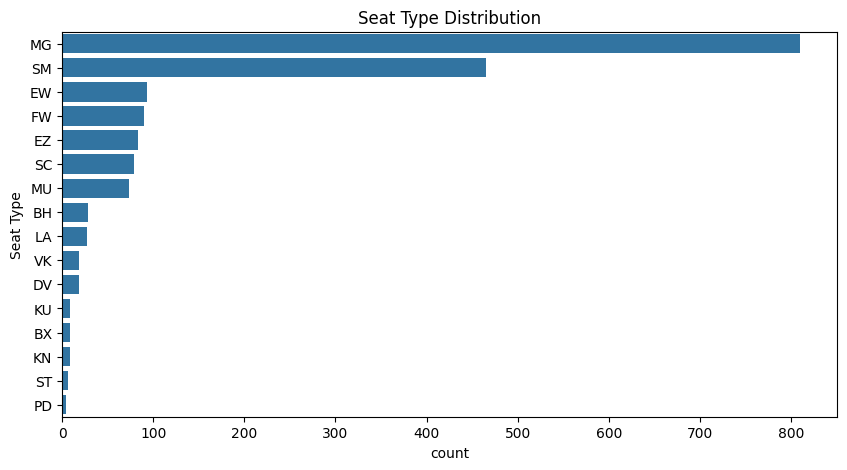

In [12]:
plt.figure(figsize=(10,5))

sns.countplot(
    y=df['Seat Type'],
    order=df['Seat Type'].value_counts().index
)

plt.title("Seat Type Distribution")
plt.show()

In [13]:
df['KEAM Rank'].describe()

count     1825.000000
mean      6594.836164
std       7852.621774
min         47.000000
25%       2301.000000
50%       4025.000000
75%       7966.000000
max      67069.000000
Name: KEAM Rank, dtype: float64

In [14]:
df['KEAM Rank'].skew()


np.float64(3.569466046413009)

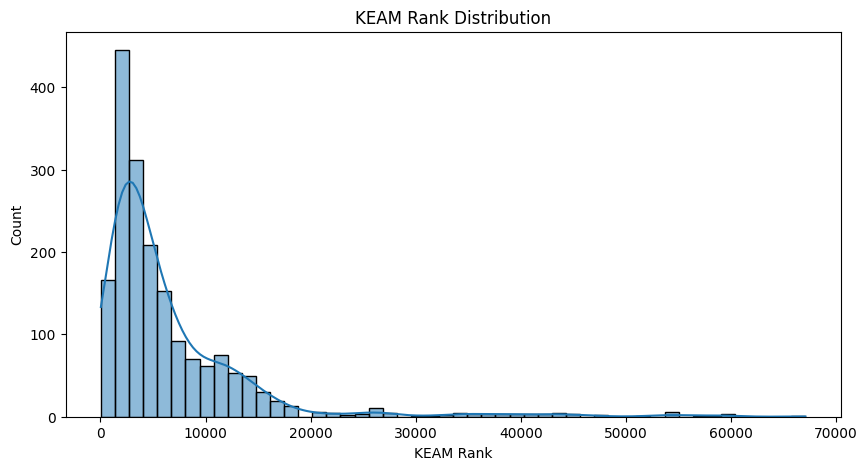

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['KEAM Rank'],
    bins=50,
    kde=True
)

plt.title("KEAM Rank Distribution")
plt.show()

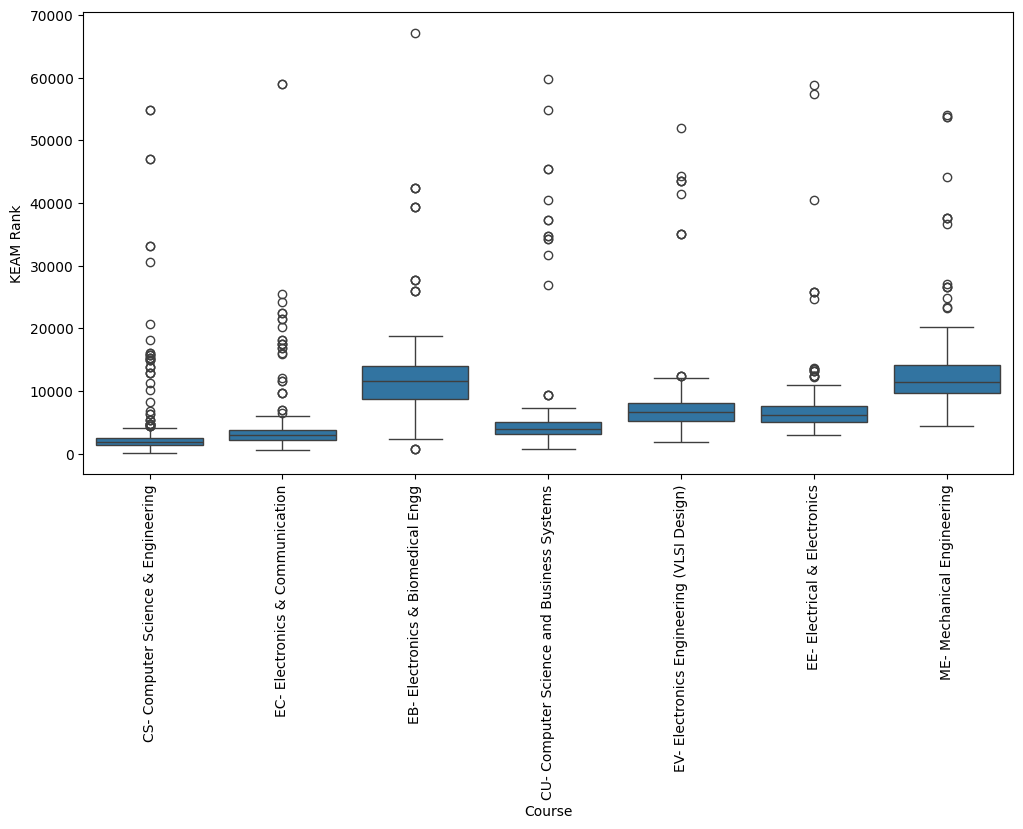

In [16]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Course',
    y='KEAM Rank',
    data=df
)

plt.xticks(rotation=90)
plt.show()

In [17]:
df.groupby('Course')['KEAM Rank'].agg(
    ['min','max','mean','median']
)

,min,max,mean,median
Course,,,,
CS- Computer Science & Engineering,47,54935,3003.054545,1904.0
CU- Computer Science and Business Systems,808,59835,6643.725275,3980.0
EB- Electronics & Biomedical Engg,810,67069,12685.098361,11598.0
EC- Electronics & Communication,635,59028,4090.772603,3060.0
EE- Electrical & Electronics,2955,58852,7856.535912,6226.0
EV- Electronics Engineering (VLSI Design),1949,52015,8202.972678,6655.0
ME- Mechanical Engineering,4359,54049,13464.397790,11531.0


In [18]:
pd.crosstab(
    df['Category'],
    df['Course']
)

Course,CS- Computer Science & Engineering,CU- Computer Science and Business Systems,EB- Electronics & Biomedical Engg,EC- Electronics & Communication,EE- Electrical & Electronics,EV- Electronics Engineering (VLSI Design),ME- Mechanical Engineering
Category,,,,,,,
BH,17,3,3,10,7,6,5
BX,6,0,3,3,0,0,0
DV,6,3,0,3,4,0,3
EW,28,9,9,19,9,11,9
EZ,42,14,23,46,26,33,30
GN,359,109,94,212,82,100,104
KN,3,0,0,3,0,3,0
KU,3,0,3,3,0,0,0
LA,6,4,3,6,3,3,3


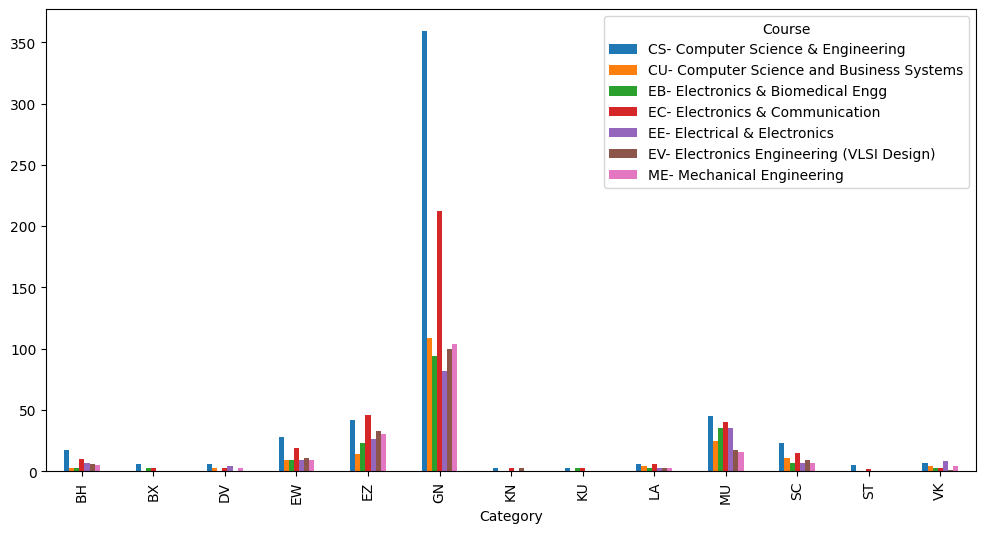

In [19]:
pd.crosstab(
    df['Category'],
    df['Course']
).plot(
    kind='bar',
    figsize=(12,6)
)

plt.show()

In [20]:
pd.crosstab(
    df['Seat Type'],
    df['Course']
)

Course,CS- Computer Science & Engineering,CU- Computer Science and Business Systems,EB- Electronics & Biomedical Engg,EC- Electronics & Communication,EE- Electrical & Electronics,EV- Electronics Engineering (VLSI Design),ME- Mechanical Engineering
Seat Type,,,,,,,
BH,9,3,3,3,3,4,3
BX,3,0,3,3,0,0,0
DV,6,3,0,3,4,0,3
EW,28,9,9,19,9,10,9
EZ,25,6,9,16,9,9,9
FW,27,9,9,18,9,9,9
KN,3,0,0,3,0,3,0
KU,3,0,3,3,0,0,0
LA,6,3,3,6,3,3,3


In [21]:
pd.crosstab(
    df['Category'],
    df['Seat Type']
)

Seat Type,BH,BX,DV,EW,EZ,FW,KN,KU,LA,MG,MU,PD,SC,SM,ST,VK
Category,,,,,,,,,,,,,,,,
BH,28,0,0,0,0,5,0,0,0,9,0,0,0,9,0,0
BX,0,9,0,0,0,0,0,0,0,0,0,0,0,3,0,0
DV,0,0,19,0,0,0,0,0,0,0,0,0,0,0,0,0
EW,0,0,0,93,0,1,0,0,0,0,0,0,0,0,0,0
EZ,0,0,0,0,83,20,0,0,0,65,0,0,0,46,0,0
GN,0,0,0,0,0,24,0,0,0,654,0,4,0,378,0,0
KN,0,0,0,0,0,0,9,0,0,0,0,0,0,0,0,0
KU,0,0,0,0,0,0,0,9,0,0,0,0,0,0,0,0
LA,0,0,0,0,0,0,0,0,27,1,0,0,0,0,0,0


In [22]:
from sklearn.preprocessing import LabelEncoder

df2 = df.copy()

le = LabelEncoder()

for col in ['Category','Course','Seat Type']:
    df2[col] = le.fit_transform(df2[col])

In [23]:
df2.corr(numeric_only=True)

,Sl. No.,KEAM Rank,Category,Course,Seat Type
Sl. No.,1.000000,0.336680,0.067996,0.205315,-0.048016
KEAM Rank,0.336680,1.000000,0.296388,0.316771,0.001860
Category,0.067996,0.296388,1.000000,-0.003506,0.386256
Course,0.205315,0.316771,-0.003506,1.000000,-0.004557
Seat Type,-0.048016,0.001860,0.386256,-0.004557,1.000000


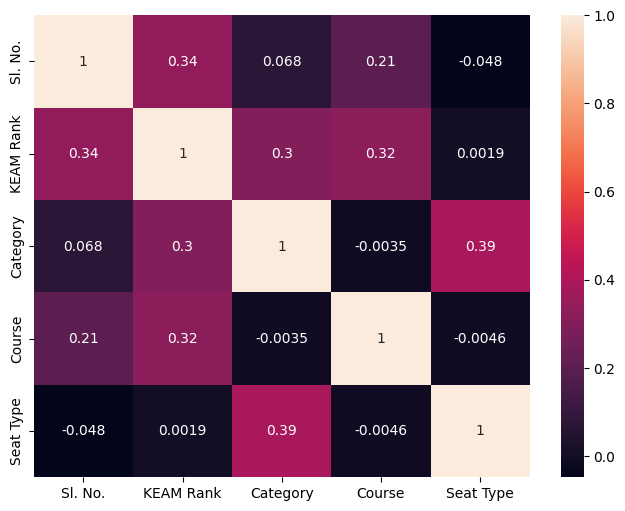

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df2.corr(numeric_only=True),
    annot=True
)

plt.show()

In [25]:
from sklearn.feature_selection import chi2

X = df2[['KEAM Rank','Category','Seat Type']]
y = df2['Course']

scores,pvalues = chi2(X,y)

pd.DataFrame({
    'Feature':X.columns,
    'Chi Score':scores,
    'P Value':pvalues
})

,Feature,Chi Score,P Value
0,KEAM Rank,3.862908e+06,0.000000
1,Category,1.550519e+01,0.016671
2,Seat Type,1.003056e+00,0.985496


In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2
import pandas as pd
import matplotlib.pyplot as plt

df2 = df.copy()

le = LabelEncoder()

for col in ['Category','Course','Seat Type']:
    df2[col] = le.fit_transform(df2[col])

X = df2[['KEAM Rank','Category']]
y = df2['Course']

scores, pvalues = chi2(X, y)

feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Chi Score': scores,
    'P Value': pvalues
})

feature_df

,Feature,Chi Score,P Value
0,KEAM Rank,3.862908e+06,0.000000
1,Category,1.550519e+01,0.016671


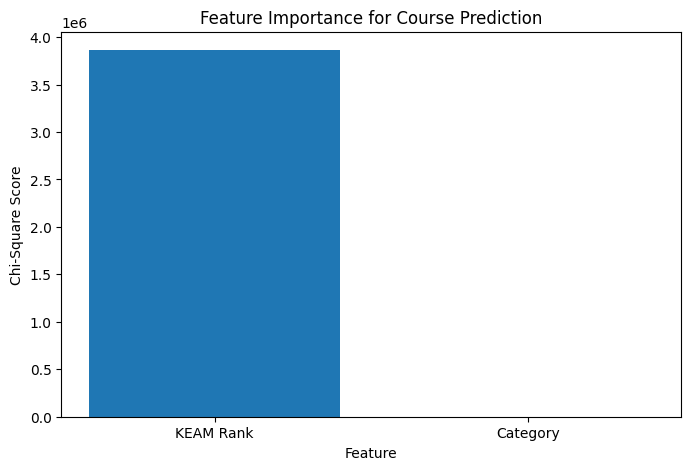

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_df['Feature'],
    feature_df['Chi Score']
)

plt.title("Feature Importance for Course Prediction")
plt.xlabel("Feature")
plt.ylabel("Chi-Square Score")

plt.show()

In [28]:
X = df2[['KEAM Rank','Category']]
y = df2['Seat Type']

scores,pvalues = chi2(X,y)

seat_feature_df = pd.DataFrame({
    'Feature':X.columns,
    'Chi Score':scores,
    'P Value':pvalues
})

seat_feature_df

,Feature,Chi Score,P Value
0,KEAM Rank,9.438408e+06,0.000000e+00
1,Category,1.087472e+03,2.352803e-222


In [7]:
df["Rank Band"] = pd.cut(
    df["KEAM Rank"],
    bins=[0,1000,3000,5000,10000,20000,50000,100000],
    labels=[
        "1-1000",
        "1001-3000",
        "3001-5000",
        "5001-10000",
        "10001-20000",
        "20001-50000",
        "50000+"
    ]
)

df[["KEAM Rank","Rank Band"]].head(10)

,KEAM Rank,Rank Band
0,47,1-1000
1,329,1-1000
2,371,1-1000
3,392,1-1000
4,460,1-1000
5,468,1-1000
6,548,1-1000
7,635,1-1000
8,648,1-1000
9,657,1-1000


In [8]:
merit = ["MG","SM"]

reservation = [
    "EZ","MU","EW","SC",
    "BH","VK","LA","DV",
    "BX","KU","KN","ST"
]

def admission_type(x):

    if x in merit:
        return "Merit"

    elif x in reservation:
        return "Reservation"

    elif x=="FW":
        return "Fee Waiver"

    elif x=="PD":
        return "PwD"

    return "Other"

df["Admission Type"] = df["Seat Type"].apply(
    admission_type
)

df[["Seat Type","Admission Type"]].head(10)

,Seat Type,Admission Type
0,SM,Merit
1,SM,Merit
2,SM,Merit
3,SM,Merit
4,SM,Merit
5,SM,Merit
6,SM,Merit
7,SM,Merit
8,SM,Merit
9,SM,Merit


In [9]:
mapping={

"CSE":"Computing",

"CSBS":"Computing",

"ECE":"Electronics",

"VLSI":"Electronics",

"Biomedical":"Electronics",

"EE":"Electrical",

"ME":"Core"

}

def branch_group(course):

    if "Computer Science" in course:
        return "Computing"

    elif "Communication" in course:
        return "Electronics"

    elif "Biomedical" in course:
        return "Electronics"

    elif "VLSI" in course:
        return "Electronics"

    elif "Electrical" in course:
        return "Electrical"

    else:
        return "Core"

df["Branch Group"] = df["Course"].apply(
    branch_group
)

df[["Course","Branch Group"]].head()

,Course,Branch Group
0,CS- Computer Science & Engineering,Computing
1,CS- Computer Science & Engineering,Computing
2,CS- Computer Science & Engineering,Computing
3,CS- Computer Science & Engineering,Computing
4,CS- Computer Science & Engineering,Computing


In [10]:
def category_group(cat):

    if cat=="GN":
        return "General"

    return "Reservation"

df["Category Group"] = df["Category"].apply(
    category_group
)

df[["Category","Category Group"]].head()

,Category,Category Group
0,GN,General
1,GN,General
2,GN,General
3,GN,General
4,GN,General


In [11]:
df[["KEAM Rank","Rank Band","Category","Category Group","Course","Branch Group","Seat Type","Admission Type"]].head()

,KEAM Rank,Rank Band,Category,Category Group,Course,Branch Group,Seat Type,Admission Type
0,47,1-1000,GN,General,CS- Computer Science & Engineering,Computing,SM,Merit
1,329,1-1000,GN,General,CS- Computer Science & Engineering,Computing,SM,Merit
2,371,1-1000,GN,General,CS- Computer Science & Engineering,Computing,SM,Merit
3,392,1-1000,GN,General,CS- Computer Science & Engineering,Computing,SM,Merit
4,460,1-1000,GN,General,CS- Computer Science & Engineering,Computing,SM,Merit


In [12]:
df.head()

,Sl. No.,KEAM Rank,Category,Course,Seat Type,Rank Band,Admission Type,Branch Group,Category Group
0,1,47,GN,CS- Computer Science & Engineering,SM,1-1000,Merit,Computing,General
1,2,329,GN,CS- Computer Science & Engineering,SM,1-1000,Merit,Computing,General
2,3,371,GN,CS- Computer Science & Engineering,SM,1-1000,Merit,Computing,General
3,4,392,GN,CS- Computer Science & Engineering,SM,1-1000,Merit,Computing,General
4,5,460,GN,CS- Computer Science & Engineering,SM,1-1000,Merit,Computing,General


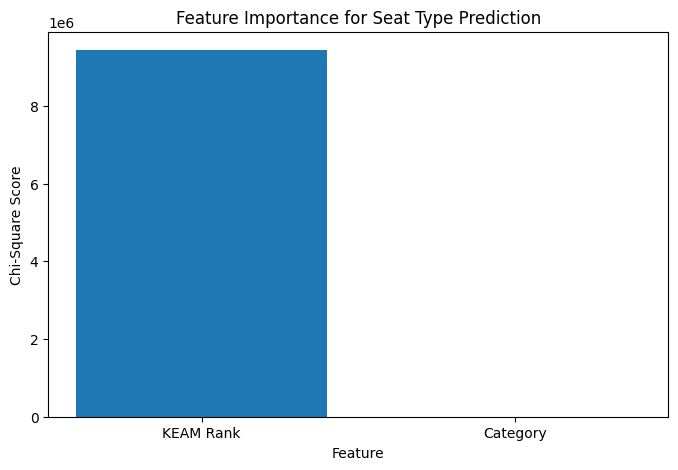

In [29]:
plt.figure(figsize=(8,5))

plt.bar(
    seat_feature_df['Feature'],
    seat_feature_df['Chi Score']
)

plt.title("Feature Importance for Seat Type Prediction")
plt.xlabel("Feature")
plt.ylabel("Chi-Square Score")

plt.show()

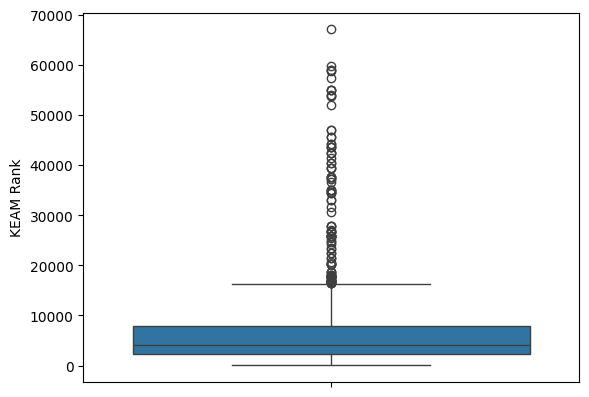

In [30]:
sns.boxplot(
    y=df['KEAM Rank']
)

plt.show()

In [31]:
df['Course'].value_counts(normalize=True)*100

Course
CS- Computer Science & Engineering           30.136986
EC- Electronics & Communication              20.000000
EB- Electronics & Biomedical Engg            10.027397
EV- Electronics Engineering (VLSI Design)    10.027397
CU- Computer Science and Business Systems     9.972603
EE- Electrical & Electronics                  9.917808
ME- Mechanical Engineering                    9.917808
Name: proportion, dtype: float64

In [35]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df_ml = df.copy()

cat_encoder = LabelEncoder()
course_encoder = LabelEncoder()
seat_encoder = LabelEncoder()

df_ml['Category'] = cat_encoder.fit_transform(df_ml['Category'])
df_ml['Course'] = course_encoder.fit_transform(df_ml['Course'])
df_ml['Seat Type'] = seat_encoder.fit_transform(df_ml['Seat Type'])

X = df_ml[['KEAM Rank','Category']]
y = df_ml['Course']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [36]:
df_ml.head()

,Sl. No.,KEAM Rank,Category,Course,Seat Type
0,1,47,5,0,13
1,2,329,5,0,13
2,3,371,5,0,13
3,4,392,5,0,13
4,5,460,5,0,13


In [71]:
from sklearn.preprocessing import LabelEncoder

df_course = df.copy()

cat_encoder = LabelEncoder()
course_encoder = LabelEncoder()

df_course['Category'] = cat_encoder.fit_transform(
    df_course['Category']
)

df_course['Course'] = course_encoder.fit_transform(
    df_course['Course']
)

In [72]:
X = df_course[['KEAM Rank','Category']]
y = df_course['Course']

In [73]:
print(X.head())

   KEAM Rank  Category
0         47         5
1        329         5
2        371         5
3        392         5
4        460         5


In [74]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_course = DecisionTreeClassifier(
    
    random_state=42
)

dt_course.fit(X_train,y_train)

pred = dt_course.predict(X_test)

print(
    "Decision Tree:",
    accuracy_score(y_test,pred)*100
)

Decision Tree: 74.24657534246575


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_course = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_course.fit(X_train,y_train)

pred = rf_course.predict(X_test)

print(
    "Random Forest:",
    accuracy_score(y_test,pred)*100
)

Random Forest: 66.02739726027397


In [77]:
from sklearn.ensemble import GradientBoostingClassifier

gb_course = GradientBoostingClassifier(
    random_state=42
)

gb_course.fit(X_train,y_train)

pred = gb_course.predict(X_test)

print(
    "Gradient Boosting:",
    accuracy_score(y_test,pred)*100
)

Gradient Boosting: 71.78082191780823


In [78]:
print(rf_course.feature_names_in_)

['KEAM Rank' 'Category']


In [79]:
sample = pd.DataFrame({
    'KEAM Rank':[3500],
    'Category':[cat_encoder.transform(['GN'])[0]]
})
pred = rf_course.predict(sample)

print(
    course_encoder.inverse_transform(pred)
)

['EC- Electronics & Communication']


In [80]:
prob = rf_course.predict_proba(sample)
for course,p in zip(
    course_encoder.classes_,
    prob[0]
):
    print(
        course,
        round(p*100,2),
        "%"
    )

CS- Computer Science & Engineering 4.2 %
CU- Computer Science and Business Systems 39.53 %
EB- Electronics & Biomedical Engg 0.42 %
EC- Electronics & Communication 41.42 %
EE- Electrical & Electronics 4.91 %
EV- Electronics Engineering (VLSI Design) 9.53 %
ME- Mechanical Engineering 0.0 %


In [102]:
from sklearn.metrics import classification_report

pred = dt_course.predict(X_test)

print(classification_report(y_test,pred))
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test,pred))

              precision    recall  f1-score   support

           0       0.86      0.87      0.87       116
           1       0.63      0.80      0.70        40
           2       0.77      0.89      0.83        38
           3       0.80      0.69      0.74        71
           4       0.78      0.68      0.72        31
           5       0.74      0.88      0.80        32
           6       0.93      0.68      0.78        37

    accuracy                           0.79       365
   macro avg       0.79      0.78      0.78       365
weighted avg       0.80      0.79      0.79       365

[[101   5   0   9   0   1   0]
 [  5  32   0   0   1   2   0]
 [  0   1  34   0   1   1   1]
 [ 11   8   1  49   1   1   0]
 [  0   4   1   2  21   2   1]
 [  0   1   0   1   2  28   0]
 [  0   0   8   0   1   3  25]]


In [114]:
sample = pd.DataFrame({
    'KEAM Rank':[1500],
    'Category':[cat_encoder.transform(['GN'])[0]]
})
prob = dt_course.predict_proba(sample)
for course,p in zip(
    course_encoder.classes_,
    prob[0]
):
    print(
        f"{course} : {round(p*100,2)}%"
    )


    results = pd.DataFrame({
    "Course": course_encoder.classes_,
    "Probability": prob[0]
})

results = results.sort_values(
    by="Probability",
    ascending=False
)

results["Probability"] = (
    results["Probability"] * 100
).round(2)

print(results)

CS- Computer Science & Engineering : 100.0%
CU- Computer Science and Business Systems : 0.0%
EB- Electronics & Biomedical Engg : 0.0%
EC- Electronics & Communication : 0.0%
EE- Electrical & Electronics : 0.0%
EV- Electronics Engineering (VLSI Design) : 0.0%
ME- Mechanical Engineering : 0.0%
                                      Course  Probability
0         CS- Computer Science & Engineering        100.0
1  CU- Computer Science and Business Systems          0.0
2          EB- Electronics & Biomedical Engg          0.0
3            EC- Electronics & Communication          0.0
4               EE- Electrical & Electronics          0.0
5  EV- Electronics Engineering (VLSI Design)          0.0
6                 ME- Mechanical Engineering          0.0


In [110]:
cat_encoder.transform(['GN'])[0]

np.int64(5)

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf_prob = RandomForestClassifier(
    n_estimators=100,
    
    random_state=42
)

rf_prob.fit(X_train,y_train)
sample = pd.DataFrame({
    'KEAM Rank':[1000],
    'Category':[cat_encoder.transform(['GN'])[0]]
})

prob = rf_prob.predict_proba(sample)
results = pd.DataFrame({
    'Course': course_encoder.classes_,
    'Probability': prob[0]
})

results = results.sort_values(
    by='Probability',
    ascending=False
)

results['Probability'] = (
    results['Probability']*100
).round(2)

print(results)

                                      Course  Probability
0         CS- Computer Science & Engineering        100.0
1  CU- Computer Science and Business Systems          0.0
2          EB- Electronics & Biomedical Engg          0.0
3            EC- Electronics & Communication          0.0
4               EE- Electrical & Electronics          0.0
5  EV- Electronics Engineering (VLSI Design)          0.0
6                 ME- Mechanical Engineering          0.0


In [147]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score


# -------------------------
# ENCODERS
# -------------------------

cat_encoder = LabelEncoder()
course_encoder = LabelEncoder()

df["Category"] = cat_encoder.fit_transform(df["Category"])
df["Course"] = course_encoder.fit_transform(df["Course"])


# -------------------------
# FEATURES & TARGET
# -------------------------

X = df[["KEAM Rank", "Category"]]
y = df["Course"]


# -------------------------
# TRAIN TEST SPLIT
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# -------------------------
# DECISION TREE
# -------------------------

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred)*100)


# -------------------------
# RANDOM FOREST
# -------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred)*100)


# -------------------------
# GRADIENT BOOSTING
# -------------------------

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test, gb_pred)*100)


svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print(
    "SVM Accuracy:",
    accuracy_score(y_test, svm_pred)*100
)


knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print(
    "KNN Accuracy:",
    accuracy_score(y_test, knn_pred)*100
)


lr_model = LogisticRegression(
    max_iter=5000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, lr_pred)*100
)

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print(
    "Naive Bayes Accuracy:",
    accuracy_score(y_test, nb_pred)*100
)



ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada_model.fit(X_train, y_train)

ada_pred = ada_model.predict(X_test)

print(
    "AdaBoost Accuracy:",
    accuracy_score(y_test, ada_pred)*100
)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print(
    "XGBoost:",
    accuracy_score(y_test, xgb_pred)*100
)



lgbm_model = LGBMClassifier(
    n_estimators=100,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

lgbm_pred = lgbm_model.predict(X_test)

print(
    "LightGBM:",
    accuracy_score(y_test, lgbm_pred)*100
)

Decision Tree Accuracy: 62.19178082191781
Random Forest Accuracy: 74.79452054794521
Gradient Boosting Accuracy: 68.21917808219177


C:\Internship\AdmissionGPT\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM Accuracy: 49.04109589041096
KNN Accuracy: 50.136986301369866


C:\Internship\AdmissionGPT\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 36.16438356164384
Naive Bayes Accuracy: 33.42465753424658
AdaBoost Accuracy: 49.589041095890416
XGBoost: 61.09589041095891
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000290 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 268
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 2
[LightGBM] [Info] Start training from score -1.199417
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -2.309458
[LightGBM] [Info] Start training from score -2.302585
[LightGBM] [Info] Start training from score -2.309458
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

In [86]:
def recommend_branches_dt(rank, category):

    category_encoded = cat_encoder.transform([category])[0]

    sample = pd.DataFrame({
        "KEAM Rank":[rank],
        "Category":[category_encoded]
    })

    probs = dt_model.predict_proba(sample)[0]

    result = pd.DataFrame({
        "Course": course_encoder.inverse_transform(
            range(len(probs))
        ),
        "Probability": probs * 100
    })

    result = result.sort_values(
        by="Probability",
        ascending=False
    )

    return result.head(2)

In [87]:
def recommend_branches_rf(rank, category):

    category_encoded = cat_encoder.transform([category])[0]

    sample = pd.DataFrame({
        "KEAM Rank":[rank],
        "Category":[category_encoded]
    })

    probs = rf_model.predict_proba(sample)[0]

    result = pd.DataFrame({
        "Course": course_encoder.inverse_transform(
            range(len(probs))
        ),
        "Probability": probs * 100
    })

    result = result.sort_values(
        by="Probability",
        ascending=False
    )

    return result.head(2)

In [88]:
def recommend_branches_gb(rank, category):

    category_encoded = cat_encoder.transform([category])[0]

    sample = pd.DataFrame({
        "KEAM Rank":[rank],
        "Category":[category_encoded]
    })

    probs = gb_model.predict_proba(sample)[0]

    result = pd.DataFrame({
        "Course": course_encoder.inverse_transform(
            range(len(probs))
        ),
        "Probability": probs * 100
    })

    result = result.sort_values(
        by="Probability",
        ascending=False
    )

    return result.head(2)

In [99]:
rank = 6000
category = "GN"

print("Decision Tree")
print(recommend_branches_dt(rank, category))

print("\nRandom Forest")
print(recommend_branches_rf(rank, category))

print("\nGradient Boosting")
print(recommend_branches_gb(rank, category))

Decision Tree
                               Course  Probability
4        EE- Electrical & Electronics        100.0
0  CS- Computer Science & Engineering          0.0

Random Forest
                                      Course  Probability
4               EE- Electrical & Electronics         88.0
1  CU- Computer Science and Business Systems          7.0

Gradient Boosting
                                      Course  Probability
4               EE- Electrical & Electronics    71.290186
5  EV- Electronics Engineering (VLSI Design)    14.184848


In [126]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score


# ----------------------------------
# MAKE A COPY
# ----------------------------------

data = df.copy()


# ----------------------------------
# ENCODERS
# ----------------------------------

cat_encoder = LabelEncoder()
course_encoder = LabelEncoder()

data["Category_Encoded"] = cat_encoder.fit_transform(data["Category"])

data["Course_Encoded"] = course_encoder.fit_transform(data["Course"])


# ----------------------------------
# FEATURES & TARGET
# ----------------------------------

X = data[["KEAM Rank", "Category_Encoded"]]

y = data["Course_Encoded"]


# ----------------------------------
# TRAIN TEST SPLIT
# ----------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ----------------------------------
# MODEL
# ----------------------------------

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)


# ----------------------------------
# ACCURACY
# ----------------------------------

pred = model.predict(X_test)

print(
    "Accuracy:",
    round(accuracy_score(y_test, pred) * 100, 2),
    "%"
)

Accuracy: 68.22 %


In [120]:
cutoff_df = pd.read_excel("../data/MEC_KEAM_Cutoff_Consolidated.xlsx")

cutoff_df.head()

,Year,Course,Admission Category,Last Rank
0,2023,Computer Science & Engineering,MG,2460.0
1,2023,Computer Science & Engineering,SM,1035.0
2,2023,Computer Science & Engineering,EZ,3459.0
3,2023,Computer Science & Engineering,MU,1759.0
4,2023,Computer Science & Engineering,EW,8612.0


In [127]:
def recommend_branches(rank, category):

    category_encoded = cat_encoder.transform(
        [category]
    )[0]

    sample = pd.DataFrame({
        "KEAM Rank": [rank],
        "Category_Encoded": [category_encoded]
    })

    probs = model.predict_proba(sample)[0]

    result = pd.DataFrame({
        "Course":
        course_encoder.inverse_transform(
            range(len(probs))
        ),

        "Probability":
        probs * 100
    })

    result = result.sort_values(
        by="Probability",
        ascending=False
    )

    return result.head(2)

In [128]:
recommend_branches(
    3500,
    "GN"
)

,Course,Probability
1,CU- Computer Science and Business Systems,60.992891
3,EC- Electronics & Communication,25.871900


In [129]:
category_map = {

    'GN':['SM','MG'],

    'EZ':['EZ','SM','MG'],
    'MU':['MU','SM','MG'],
    'EW':['EW','SM','MG'],

    'SC':['SC','SM','MG'],
    'ST':['ST','SM','MG'],

    'VK':['VK','SM','MG'],
    'BH':['BH','SM','MG'],
    'LA':['LA','SM','MG'],
    'KN':['KN','SM','MG'],
    'KU':['KU','SM','MG'],
    'BX':['BX','SM','MG'],
    'DV':['DV','SM','MG']
}

In [130]:
def chance_level(rank, cutoff):

    difference = cutoff - rank

    if difference >= 3000:
        return "Very High Chance"

    elif difference >= 1000:
        return "High Chance"

    elif difference >= -1000:
        return "Possible"

    elif difference >= -5000:
        return "Low Chance"

    else:
        return "Not Likely"

In [131]:
def analyze_cutoffs(rank, category):

    eligible_categories = category_map[category]

    results = []

    for adm_cat in eligible_categories:

        temp = cutoff_df[
            cutoff_df["Admission Category"] == adm_cat
        ]

        for course in temp["Course"].unique():

            course_data = temp[
                temp["Course"] == course
            ]

            avg_cutoff = course_data["Last Rank"].mean()

            if pd.isna(avg_cutoff):
                continue

            chance = chance_level(rank, avg_cutoff)

            results.append([
                course,
                adm_cat,
                round(avg_cutoff),
                chance
            ])

    return pd.DataFrame(
        results,
        columns=[
            "Course",
            "Admission Category",
            "Average Cutoff",
            "Chance"
        ]
    )

In [132]:
def admission_gpt(rank, category):

    print("="*60)
    print("BRANCH PREFERENCE PREDICTION")
    print("="*60)

    top_branches = recommend_branches(
        rank,
        category
    )

    print(top_branches)

    print("\n")

    print("="*60)
    print("ADMISSION CHANCE ANALYSIS")
    print("="*60)

    chances = analyze_cutoffs(
        rank,
        category
    )

    return chances.sort_values(
        by="Average Cutoff",
        ascending=True
    )

In [133]:
result = admission_gpt(
    rank=3500,
    category='GN'
)

result

BRANCH PREFERENCE PREDICTION
                                      Course  Probability
1  CU- Computer Science and Business Systems    60.992891
3            EC- Electronics & Communication    25.871900


ADMISSION CHANCE ANALYSIS


,Course,Admission Category,Average Cutoff,Chance
0,Computer Science & Engineering,SM,1289,Low Chance
3,Electronics & Communication,SM,2563,Possible
7,Computer Science & Engineering,MG,2758,Possible
1,Computer Science and Business Systems,SM,3350,Possible
10,Electronics & Communication,MG,4611,High Chance
8,Computer Science and Business Systems,MG,5372,High Chance
4,Electrical & Electronics,SM,5393,High Chance
5,Electronics Engineering (VLSI Design),SM,7129,Very High Chance
11,Electrical & Electronics,MG,9092,Very High Chance
2,Electronics & Biomedical Engg,SM,10438,Very High Chance


In [134]:
import joblib

In [135]:
joblib.dump(model, "branch_model.pkl")

joblib.dump(cat_encoder, "cat_encoder.pkl")

joblib.dump(course_encoder,
            "course_encoder.pkl")

['course_encoder.pkl']

In [2]:
import joblib

model = joblib.load(
    "branch_model.pkl"
)

cat_encoder = joblib.load(
    "cat_encoder.pkl"
)

course_encoder = joblib.load(
    "course_encoder.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: 'branch_model.pkl'

In [150]:
recommend_branches(
    3500,
    "GN"
)

,Course,Probability
1,CU- Computer Science and Business Systems,60.992891
3,EC- Electronics & Communication,25.871900


In [151]:
result = admission_gpt(
    rank=3500,
    category="ST"
)
result

BRANCH PREFERENCE PREDICTION
                                      Course  Probability
0         CS- Computer Science & Engineering    55.634293
1  CU- Computer Science and Business Systems    29.210399


ADMISSION CHANCE ANALYSIS


,Course,Admission Category,Average Cutoff,Chance
7,Computer Science & Engineering,SM,1289,Low Chance
10,Electronics & Communication,SM,2563,Possible
14,Computer Science & Engineering,MG,2758,Possible
8,Computer Science and Business Systems,SM,3350,Possible
17,Electronics & Communication,MG,4611,High Chance
15,Computer Science and Business Systems,MG,5372,High Chance
11,Electrical & Electronics,SM,5393,High Chance
12,Electronics Engineering (VLSI Design),SM,7129,Very High Chance
18,Electrical & Electronics,MG,9092,Very High Chance
9,Electronics & Biomedical Engg,SM,10438,Very High Chance


In [159]:
from flaml import AutoML

from sklearn.metrics import accuracy_score

# -------------------------
# AUTOML
# -------------------------

automl = AutoML()

automl.fit(
    X_train=X_train,
    y_train=y_train,
    task="classification",
    metric="accuracy",
    time_budget=60,
    verbose=1
)

# -------------------------
# BEST MODEL
# -------------------------

print("\nBEST ESTIMATOR")
print(automl.best_estimator)

print("\nBEST CONFIG")
print(automl.best_config)

# -------------------------
# TEST ACCURACY
# -------------------------

pred = automl.predict(X_test)

acc = accuracy_score(
    y_test,
    pred
)

print(
    f"\nAutoML Accuracy: {acc*100:.2f}%"
)


BEST ESTIMATOR
lgbm

BEST CONFIG
{'n_estimators': 19, 'num_leaves': 17, 'min_child_samples': 4, 'learning_rate': np.float64(0.45125765723119426), 'log_max_bin': 10, 'colsample_bytree': np.float64(0.9914743451264505), 'reg_alpha': np.float64(0.0015564673105246884), 'reg_lambda': np.float64(0.12979901231788393)}

AutoML Accuracy: 66.85%


In [158]:
from autogluon.tabular import TabularPredictor

train_data = pd.concat(
    [X_train, y_train],
    axis=1
)

test_data = pd.concat(
    [X_test, y_test],
    axis=1
)

predictor = TabularPredictor(
    label='Course',
    eval_metric='accuracy'
)

predictor.fit(
    train_data,
    presets='best_quality'
)

leaderboard = predictor.leaderboard(
    test_data,
    silent=True
)

print(leaderboard)

ModuleNotFoundError: No module named 'autogluon'

In [8]:
import joblib

# Load using the absolute path to your file
model = joblib.load(r"C:\Internship\AdmissionGPT\models\branch_model.pkl")

# Print the feature names
print("Features expected by the model:", model.feature_names_in_)



Features expected by the model: ['KEAM Rank' 'Category_Encoded']
